<a href="https://colab.research.google.com/github/cerenk44/plant-disease-detection/blob/main/Plant_Disease_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile

os.environ['KAGGLE_API_TOKEN'] = "KGAT_a061c30c0c891860033443f7acf2cf2f"

# Kaggle kütüphanesini kuruma
!pip install -q kaggle

print("Veri seti indiriliyor, lütfen bekleyin (Bu işlem birkaç dakika sürebilir)...")
# Veri setini indirme
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

print("İndirme tamamlandı. Zip dosyası çıkartılıyor...")
# İnen zip dosyasını klasöre çıkartma
zip_ref = zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r')
zip_ref.extractall('dataset')
zip_ref.close()

print("İşlem Başarılı! Veri setimiz hazır.")

Veri seti indiriliyor, lütfen bekleyin (Bu işlem birkaç dakika sürebilir)...
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:27<00:00, 104MB/s]

İndirme tamamlandı. Zip dosyası çıkartılıyor...
İşlem Başarılı! Veri setimiz hazır.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# İndirilen verilerin bulunduğu klasör yollar
train_dir = 'dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = 'dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

# Pikselleri 0-255 arasından 0-1 arasına çekme (Normalizasyon)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

print("Eğitim (Train) verileri hazırlanıyor...")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224), # Tüm resimleri 224x224 piksel yapma
    batch_size=32,          # Resimleri 32'şerli gruplara bölme
    class_mode='categorical'# Çoklu sınıflandırma
)

print("\nDoğrulama (Validation) verileri hazırlanıyor...")
valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Eğitim (Train) verileri hazırlanıyor...
Found 70295 images belonging to 38 classes.

Doğrulama (Validation) verileri hazırlanıyor...
Found 17572 images belonging to 38 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Boş bir model
model = Sequential()

# Evrişim (Convolution) Katmanı: Resimdeki temel kenarları ve çizgileri bulur
# 224x224 piksel ve 3 renk kanallı (RGB) resimler girdi olarak veriliyor
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
# Havuzlama (Pooling) Katmanı: Boyutu küçültüp önemli özellikleri öne çıkarır
model.add(MaxPooling2D((2, 2)))

# 3. Evrişim Katmanı: Daha karmaşık şekilleri (leke, doku, çürüklük) bulur
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 4. Evrişim Katmanı: Artık resmin genel hastalığını anlamaya başlar
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 5. Düzleştirme (Flatten): 2 boyutlu resim matrisini tek boyutlu bir listeye çevirir
model.add(Flatten())

# 6. Tam Bağlı (Fully Connected) Katmanlar: Karar verme mekanizması
model.add(Dense(512, activation='relu'))
# Dropout: Nöronların %50'sini rastgele kapatarak modelin ezberlemesini (overfitting) önleniyor
model.add(Dropout(0.5))

# 7. Çıkış (Output) Katmanı: 38 farklı hastalık/sağlam sınıfımız olduğu için 38 nöron koyar
# Softmax aktivasyonu, resmin hangi hastalığa ait olma olasılığını yüzdelik olarak verir
model.add(Dense(38, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,415,590 (169.43 MB)

 Trainable params: 44,415,590 (169.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Modeli Derleme (Compile)
model.compile(
    optimizer='adam', # Modeli en iyi optimize eden algoritma (Endüstri standardıdır)
    loss='categorical_crossentropy', # Çok sınıflı hataları hesaplama formülü
    metrics=['accuracy'] # Başarımızı "Doğruluk Oranı" üzerinden takip edeceğiz
)

print("Model başarıyla derlendi. Eğitim başlıyor! (Bu işlem biraz vakit alabilir)...")

# 2. Modeli Eğitme (Fit)
# Epochs=10: Model tüm veri setini 10 kere baştan sona okuyup öğrenecek
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Model başarıyla derlendi. Eğitim başlıyor! (Bu işlem biraz vakit alabilir)...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 190s 82ms/step - accuracy: 0.6698 - loss: 1.1132 - val_accuracy: 0.8854 - val_loss: 0.3568
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 171s 78ms/step - accuracy: 0.8687 - loss: 0.4183 - val_accuracy: 0.9326 - val_loss: 0.2060
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 76ms/step - accuracy: 0.9102 - loss: 0.2756 - val_accuracy: 0.9125 - val_loss: 0.2808
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 169s 77ms/step - accuracy: 0.9325 - loss: 0.2118 - val_accuracy: 0.9290 - val_loss: 0.2260
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 176s 80ms/step - accuracy: 0.9447 - loss: 0.1747 - val_accuracy: 0.9402 - val_loss: 0.1928
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9539 - loss: 0.1475 - val_accuracy: 0.9425 - val_loss: 0.2015
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 171s 78ms/step - accuracy: 0.9619 - loss: 0.1234 - val_accuracy: 0.9412 - val_loss

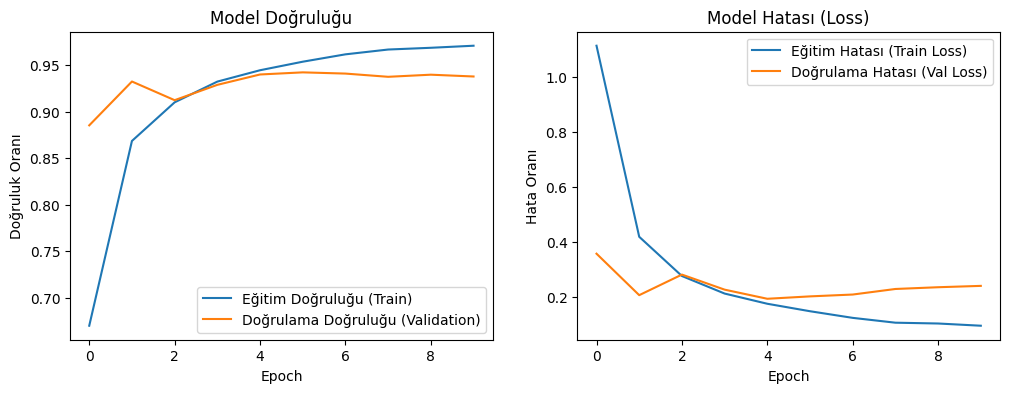

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train)')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu (Validation)')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk Oranı')
plt.legend()

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Hatası (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Hatası (Val Loss)')
plt.title('Model Hatası (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Hata Oranı')
plt.legend()

plt.show()

In [ ]:
model.save('plant_disease_model.h5')
print("Model başarıyla kaydedildi!")

Model başarıyla kaydedildi!


In [ ]:
print("Modelin hafızası test ediliyor...")
model.evaluate(valid_data)

Modelin hafızası test ediliyor...
550/550 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9380 - loss: 0.2397


[0.23974397778511047, 0.9380264282226562]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


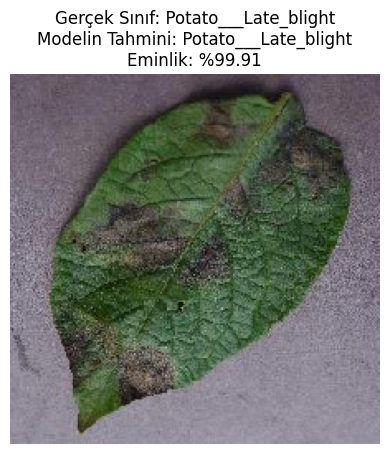

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sınıf sözlüğümüzün bellekte olduğundan emin olalım
sinif_isimleri = {v: k for k, v in train_data.class_indices.items()}

# Doğrulama (validation) setimizden rastgele bir grup resim alalım
x_batch, y_batch = next(valid_data)

# Gruptaki ilk resmi seçelim
test_resmi = x_batch[0]
gercek_etiket_id = np.argmax(y_batch[0])

# Modeli tahmin ettirelim (Resim zaten 0-1 arasına çekilmiş olduğu için tekrar /255.0 YAPMIYORUZ)
tahmin = model.predict(np.expand_dims(test_resmi, axis=0))
tahmin_id = np.argmax(tahmin[0])

# İsimleri sözlükten eşleştirelim
gercek_hastalik = sinif_isimleri[gercek_etiket_id]
tahmin_edilen = sinif_isimleri[tahmin_id]

# Sonucu çizdirelim
plt.imshow(test_resmi)
plt.title(f"Gerçek Sınıf: {gercek_hastalik}\nModelin Tahmini: {tahmin_edilen}\nEminlik: %{np.max(tahmin[0])*100:.2f}")
plt.axis('off')
plt.show()